## MACHINE LEARNING TASK


## Import Important Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## LOAD DATA SET


In [ ]:
df = pd.read_csv(r'C:\Users\win11\Desktop\blinkit-sales-analytics\blinkit_data_backup.csv')
df

In [ ]:
df.columns

## Explorartory Data Analysis


In [ ]:
df.head(10)

In [ ]:
df.isnull()

In [ ]:
df.isnull().sum()

In [ ]:
df.describe()

In [ ]:
df.shape

In [ ]:
df.duplicated()

In [ ]:
df.duplicated().sum()

In [ ]:
df.info()

In [ ]:
df.columns

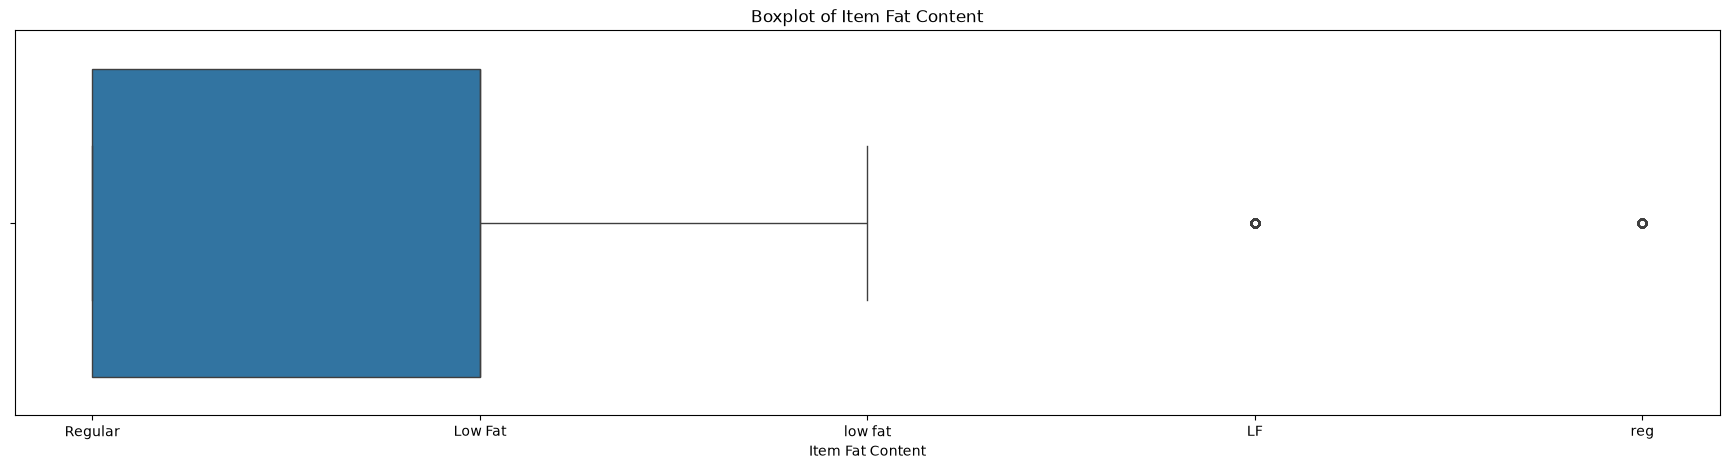

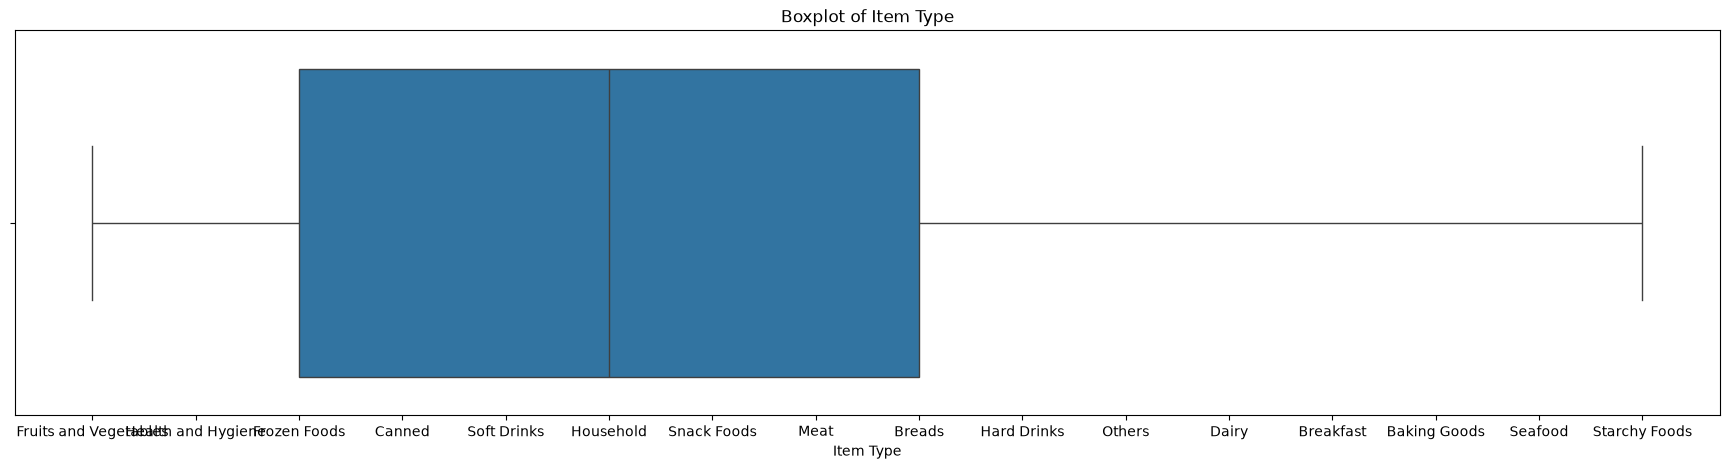

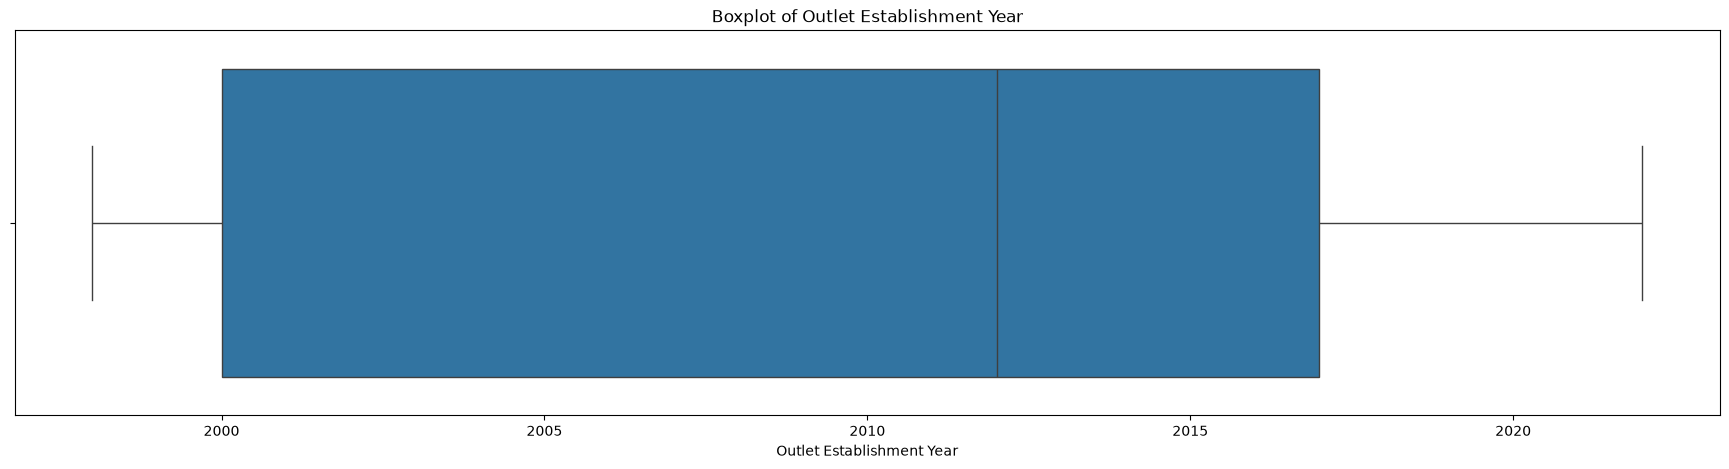

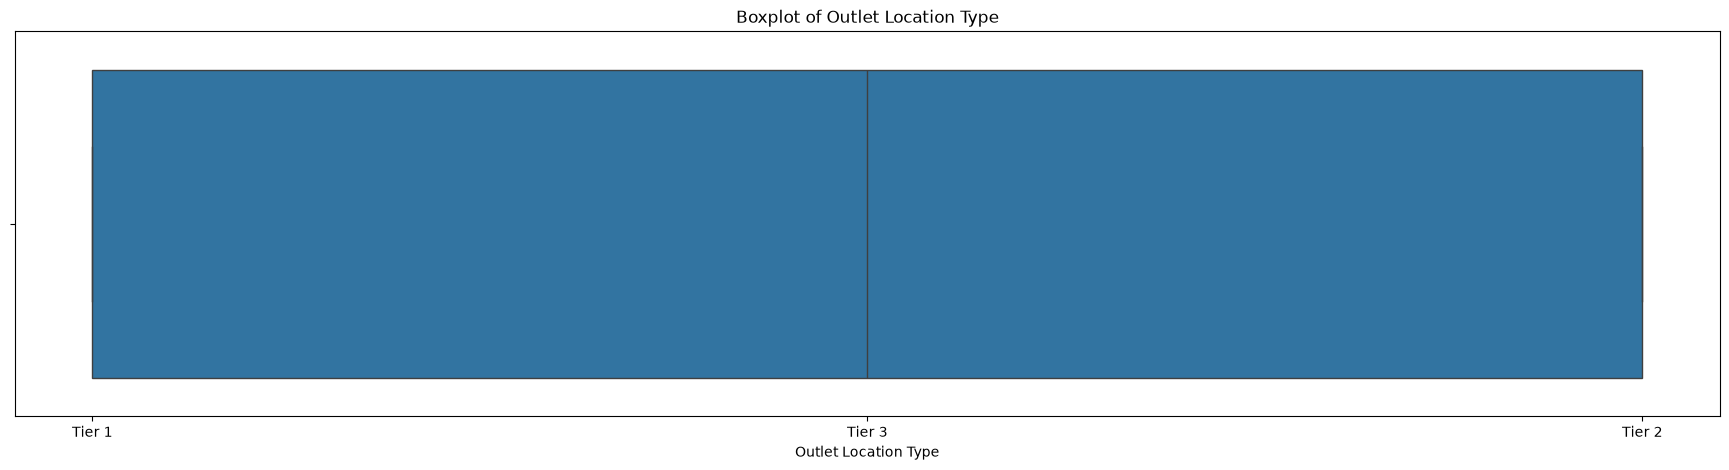

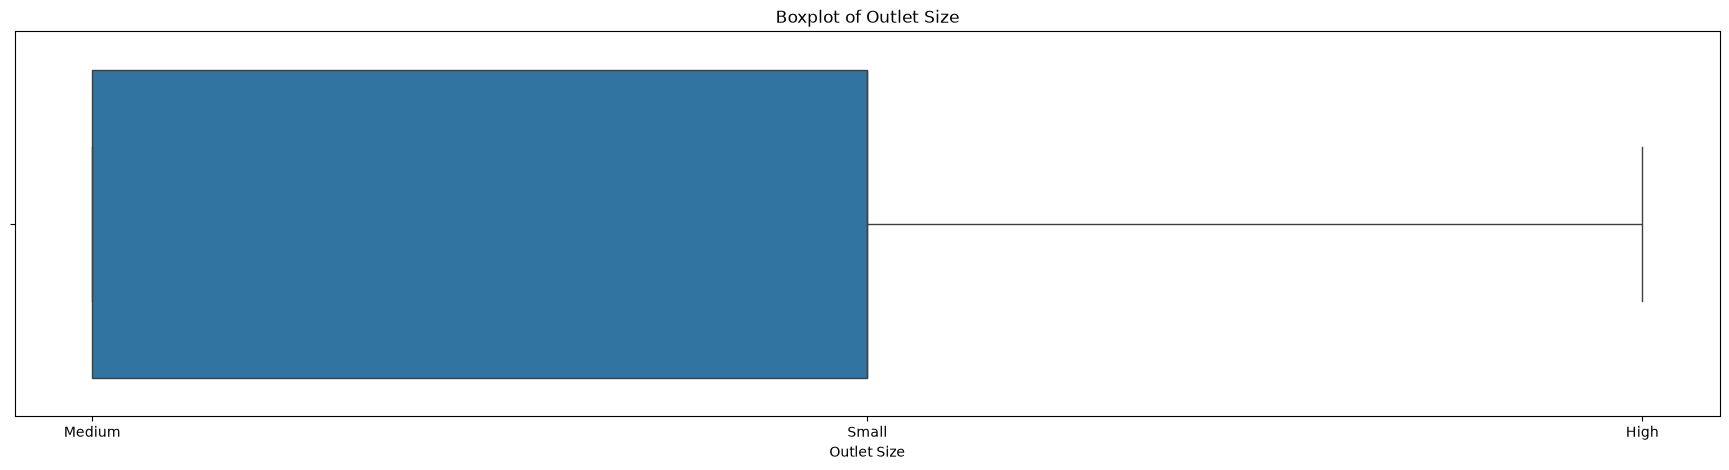

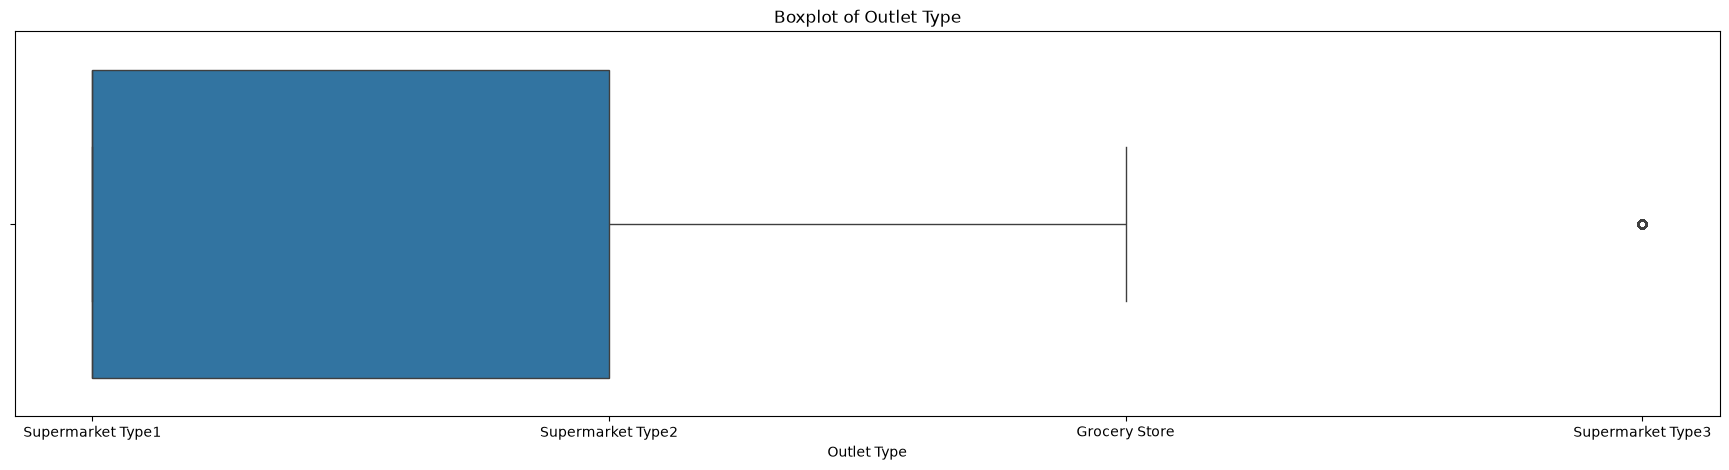

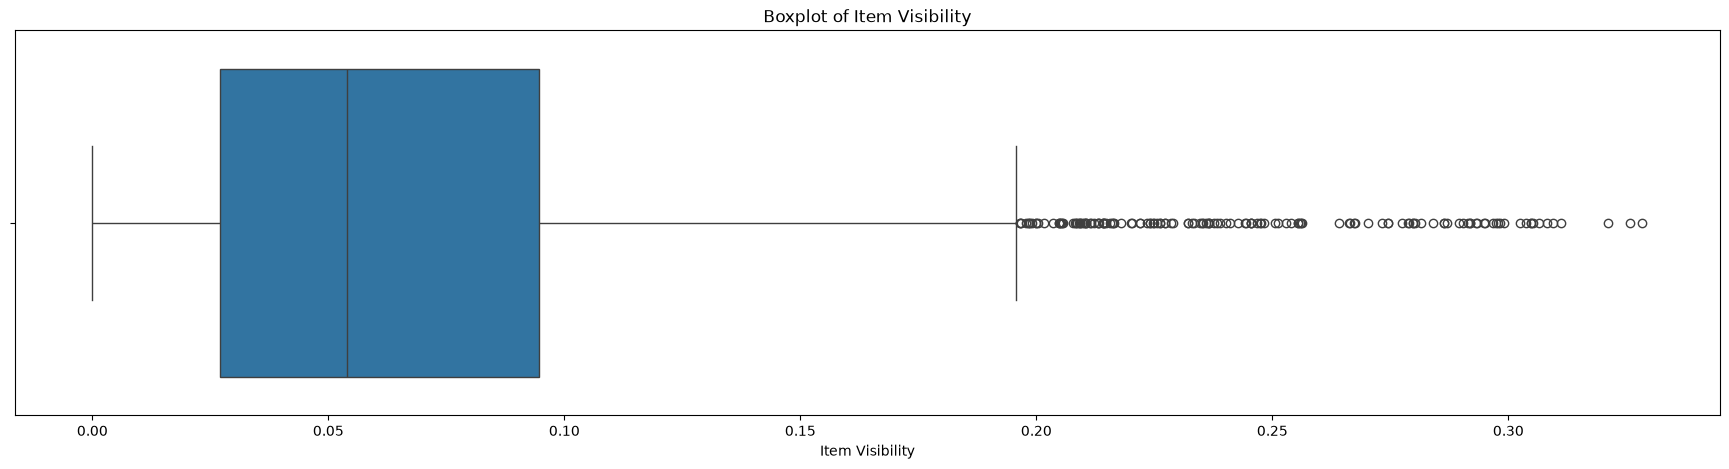

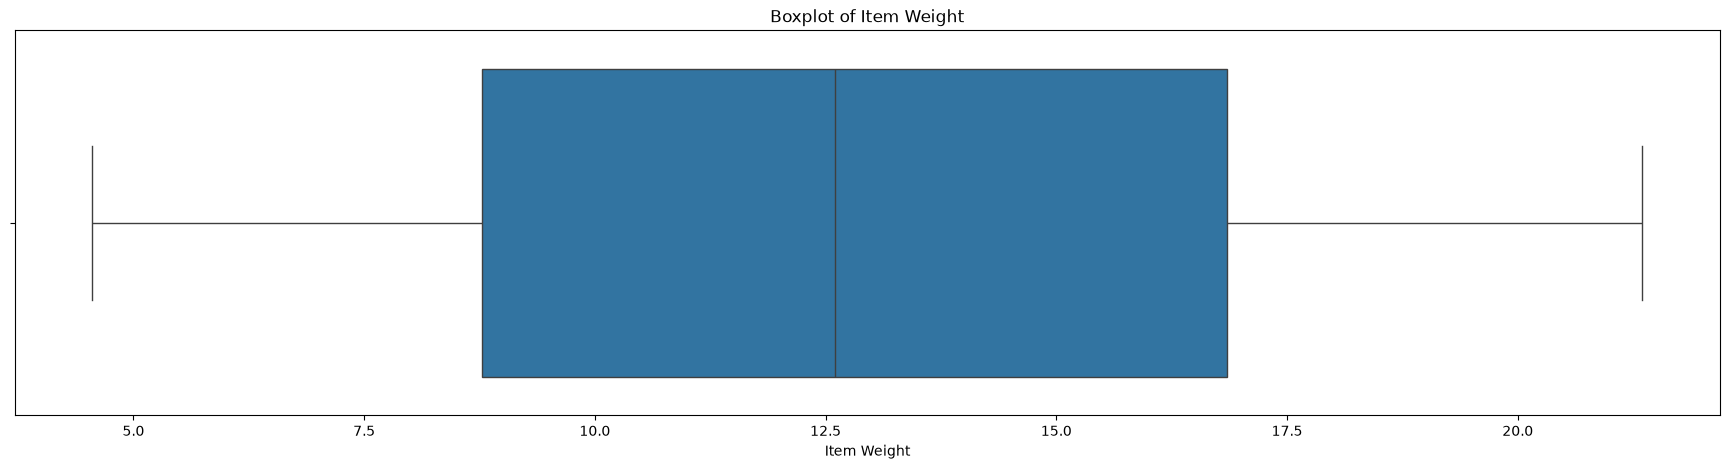

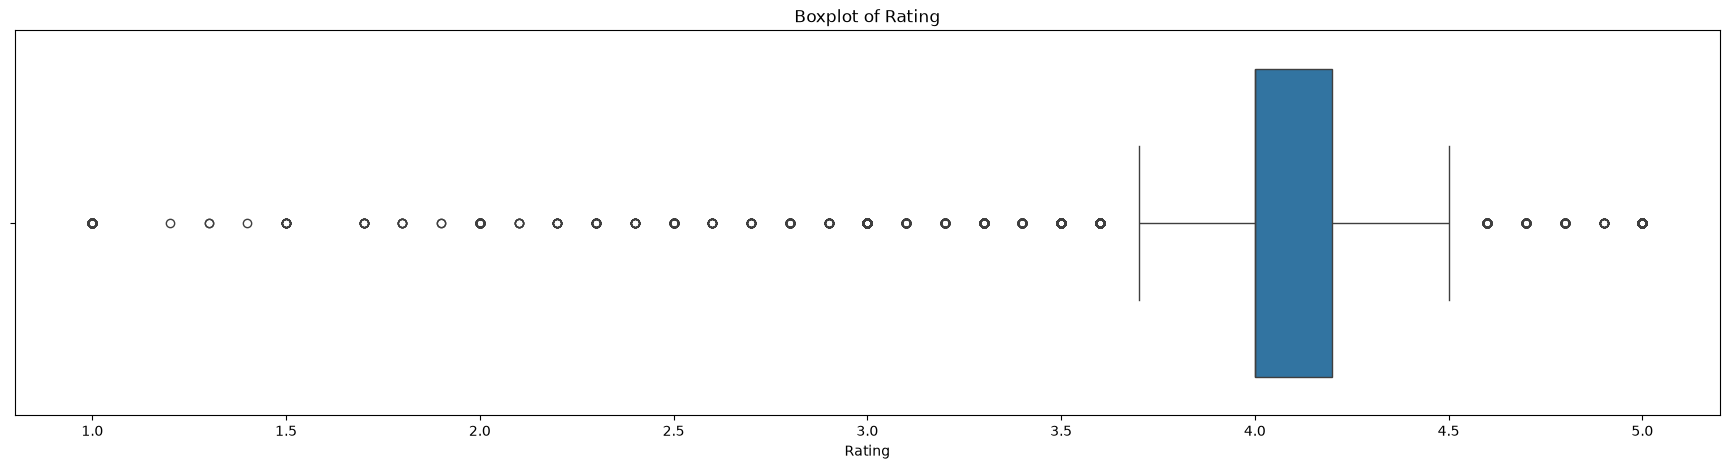

In [117]:
numericals_columns = [
    'Item Fat Content',
    'Item Type',
    'Outlet Establishment Year',
    'Outlet Location Type',
    'Outlet Size',
    'Outlet Type',
    'Item Visibility',
    'Item Weight',
    'Rating'
]

for col in numericals_columns:
    plt.figure(figsize=(22, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [118]:
df['Sales'].value_counts()

Sales
172.0422    7
170.5422    6
188.1872    6
196.5768    6
196.5084    6
           ..
149.1734    1
78.9986     1
241.6828    1
97.8752     1
112.2544    1
Name: count, Length: 5938, dtype: int64

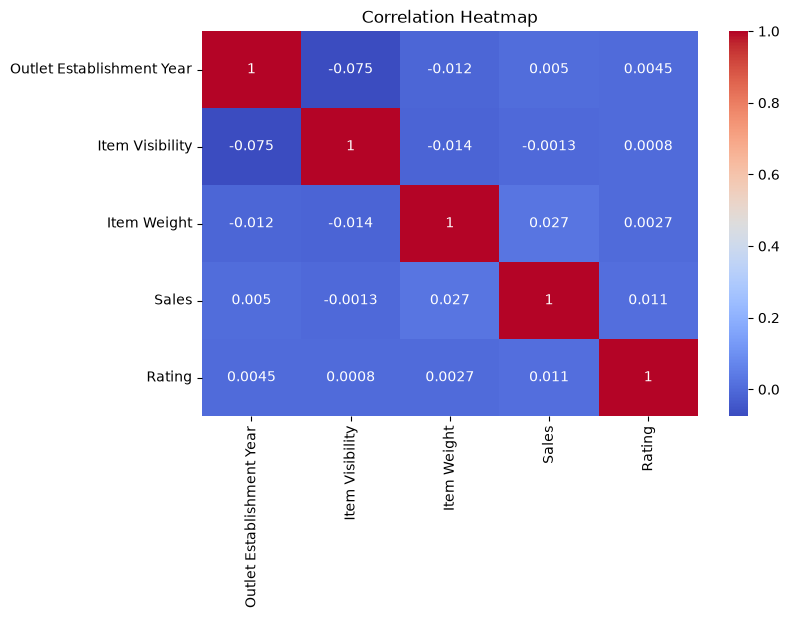

In [119]:

plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap = "coolwarm")

plt.title("Correlation Heatmap")
plt.show()

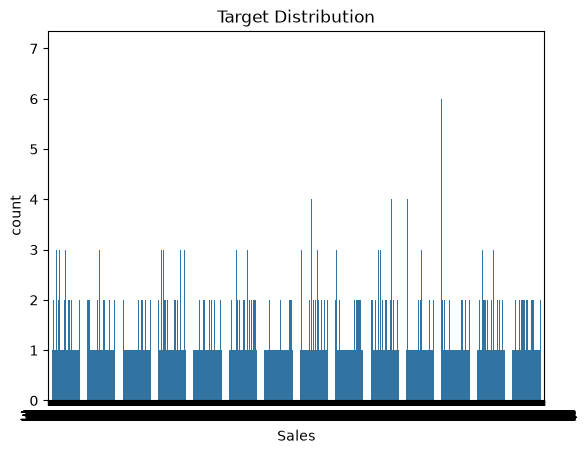

In [120]:
sns.countplot(x=df["Sales"])

plt.title("Target Distribution")
plt.show()

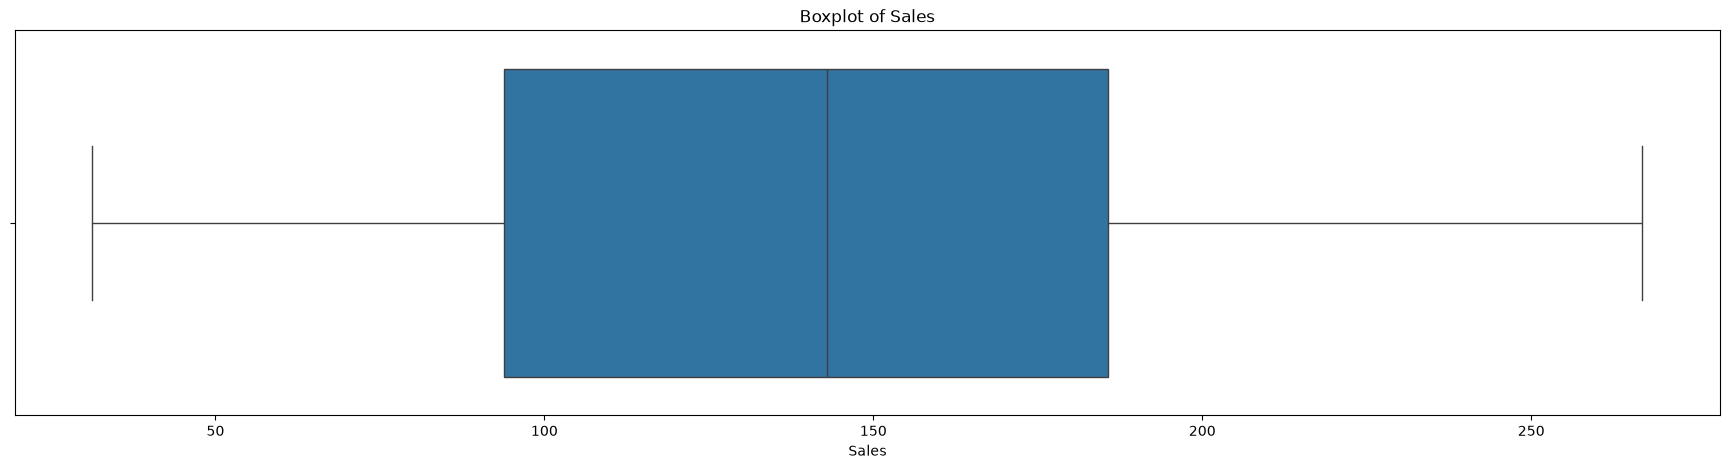

In [121]:
plt.figure(figsize=(22, 5))
sns.boxplot(x=df['Sales'])
plt.title('Boxplot of Sales')
plt.show()

## DATA CLEANING


In [122]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [123]:
df['Item Weight'].isnull().sum()

np.int64(1463)

In [124]:
mean_item_weight = round(df['Item Weight'].mean() , 2)
mean_item_weight

np.float64(12.86)

In [125]:
df['Item Weight'] = df['Item Weight'].fillna(mean_item_weight)

In [126]:
df['Item Weight'].isnull().sum()

np.int64(0)

In [127]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [128]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat', 'reg': 'Regular' , 
'low fat': 'Low Fat'})
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,Low Fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,12.86,181.9292,5.0


In [129]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [130]:
df['Item Type'].unique()

<StringArray>
['Fruits and Vegetables',    'Health and Hygiene',          'Frozen Foods',
                'Canned',           'Soft Drinks',             'Household',
           'Snack Foods',                  'Meat',                'Breads',
           'Hard Drinks',                'Others',                 'Dairy',
             'Breakfast',          'Baking Goods',               'Seafood',
         'Starchy Foods']
Length: 16, dtype: str

In [131]:
df['Outlet Location Type'].unique()

<StringArray>
['Tier 1', 'Tier 3', 'Tier 2']
Length: 3, dtype: str

In [132]:
df['Outlet Size'].unique()

<StringArray>
['Medium', 'Small', 'High']
Length: 3, dtype: str

In [133]:
df['Outlet Type'].unique()

<StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str

## DATA PROCESSING


In [134]:
encoding_item_fat_content = {
    "Low Fat": 0,
    "Regular": 1
}

df["Item Fat Content"] = df["Item Fat Content"].map(encoding_item_fat_content)
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,1,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,0,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,1,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,1,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,0,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,0,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,0,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,0,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,0,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,0,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,12.86,181.9292,5.0


In [135]:
encoding_outlet_size = {
    "Small": 0,
    "Medium": 1,
    "High": 2
}

df["Outlet Size"] = df["Outlet Size"].map(encoding_outlet_size)
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,1,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,1,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,0,NCB42,Health and Hygiene,2022,OUT018,Tier 3,1,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,1,FDR28,Frozen Foods,2010,OUT046,Tier 1,0,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,1,FDL50,Canned,2000,OUT013,Tier 3,2,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,0,DRI25,Soft Drinks,2015,OUT045,Tier 2,0,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,0,FDS52,Frozen Foods,2020,OUT017,Tier 2,0,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,0,NCU05,Health and Hygiene,2011,OUT010,Tier 3,0,Grocery Store,0.098312,11.80,81.4618,5.0
7,0,NCD30,Household,2015,OUT045,Tier 2,0,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,0,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,2,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,0,FDX25,Canned,1998,OUT027,Tier 3,1,Supermarket Type3,0.101562,12.86,181.9292,5.0


In [136]:
cols = ["Item Type", "Outlet Location Type" ,"Outlet Type" ]

df = pd.get_dummies(df, columns=cols, dtype=int)
df.head(10)

,Item Fat Content,Item Identifier,Outlet Establishment Year,Outlet Identifier,Outlet Size,Item Visibility,Item Weight,Sales,Rating,Item Type_Baking Goods,...,Item Type_Snack Foods,Item Type_Soft Drinks,Item Type_Starchy Foods,Outlet Location Type_Tier 1,Outlet Location Type_Tier 2,Outlet Location Type_Tier 3,Outlet Type_Grocery Store,Outlet Type_Supermarket Type1,Outlet Type_Supermarket Type2,Outlet Type_Supermarket Type3
0,1,FDX32,2012,OUT049,1,0.100014,15.10,145.4786,5.0,0,...,0,0,0,1,0,0,0,1,0,0
1,0,NCB42,2022,OUT018,1,0.008596,11.80,115.3492,5.0,0,...,0,0,0,0,0,1,0,0,1,0
2,1,FDR28,2010,OUT046,0,0.025896,13.85,165.0210,5.0,0,...,0,0,0,1,0,0,0,1,0,0
3,1,FDL50,2000,OUT013,2,0.042278,12.15,126.5046,5.0,0,...,0,0,0,0,0,1,0,1,0,0
4,0,DRI25,2015,OUT045,0,0.033970,19.60,55.1614,5.0,0,...,0,1,0,0,1,0,0,1,0,0
5,0,FDS52,2020,OUT017,0,0.005505,8.89,102.4016,5.0,0,...,0,0,0,0,1,0,0,1,0,0
6,0,NCU05,2011,OUT010,0,0.098312,11.80,81.4618,5.0,0,...,0,0,0,0,0,1,1,0,0,0
7,0,NCD30,2015,OUT045,0,0.026904,19.70,96.0726,5.0,0,...,0,0,0,0,1,0,0,1,0,0
8,0,FDW20,2000,OUT013,2,0.024129,20.75,124.1730,5.0,0,...,0,0,0,0,0,1,0,1,0,0
9,0,FDX25,1998,OUT027,1,0.101562,12.86,181.9292,5.0,0,...,0,0,0,0,0,1,0,0,0,1


In [137]:
# Save the cleaned and encoded dataset
df.to_csv("blinkit_clean_data.csv", index=False)

In [138]:
df_cleaned = pd . read_csv ("blinkit_clean_data.csv")

In [139]:
df_cleaned.head(10)

,Item Fat Content,Item Identifier,Outlet Establishment Year,Outlet Identifier,Outlet Size,Item Visibility,Item Weight,Sales,Rating,Item Type_Baking Goods,...,Item Type_Snack Foods,Item Type_Soft Drinks,Item Type_Starchy Foods,Outlet Location Type_Tier 1,Outlet Location Type_Tier 2,Outlet Location Type_Tier 3,Outlet Type_Grocery Store,Outlet Type_Supermarket Type1,Outlet Type_Supermarket Type2,Outlet Type_Supermarket Type3
0,1,FDX32,2012,OUT049,1,0.100014,15.10,145.4786,5.0,0,...,0,0,0,1,0,0,0,1,0,0
1,0,NCB42,2022,OUT018,1,0.008596,11.80,115.3492,5.0,0,...,0,0,0,0,0,1,0,0,1,0
2,1,FDR28,2010,OUT046,0,0.025896,13.85,165.0210,5.0,0,...,0,0,0,1,0,0,0,1,0,0
3,1,FDL50,2000,OUT013,2,0.042278,12.15,126.5046,5.0,0,...,0,0,0,0,0,1,0,1,0,0
4,0,DRI25,2015,OUT045,0,0.033970,19.60,55.1614,5.0,0,...,0,1,0,0,1,0,0,1,0,0
5,0,FDS52,2020,OUT017,0,0.005505,8.89,102.4016,5.0,0,...,0,0,0,0,1,0,0,1,0,0
6,0,NCU05,2011,OUT010,0,0.098312,11.80,81.4618,5.0,0,...,0,0,0,0,0,1,1,0,0,0
7,0,NCD30,2015,OUT045,0,0.026904,19.70,96.0726,5.0,0,...,0,0,0,0,1,0,0,1,0,0
8,0,FDW20,2000,OUT013,2,0.024129,20.75,124.1730,5.0,0,...,0,0,0,0,0,1,0,1,0,0
9,0,FDX25,1998,OUT027,1,0.101562,12.86,181.9292,5.0,0,...,0,0,0,0,0,1,0,0,0,1


In [140]:
df_cleaned.dtypes

Item Fat Content                     int64
Item Identifier                        str
Outlet Establishment Year            int64
Outlet Identifier                      str
Outlet Size                          int64
Item Visibility                    float64
Item Weight                        float64
Sales                              float64
Rating                             float64
Item Type_Baking Goods               int64
Item Type_Breads                     int64
Item Type_Breakfast                  int64
Item Type_Canned                     int64
Item Type_Dairy                      int64
Item Type_Frozen Foods               int64
Item Type_Fruits and Vegetables      int64
Item Type_Hard Drinks                int64
Item Type_Health and Hygiene         int64
Item Type_Household                  int64
Item Type_Meat                       int64
Item Type_Others                     int64
Item Type_Seafood                    int64
Item Type_Snack Foods                int64
Item Type_S

In [141]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item Fat Content                 8523 non-null   int64  
 1   Item Identifier                  8523 non-null   str    
 2   Outlet Establishment Year        8523 non-null   int64  
 3   Outlet Identifier                8523 non-null   str    
 4   Outlet Size                      8523 non-null   int64  
 5   Item Visibility                  8523 non-null   float64
 6   Item Weight                      8523 non-null   float64
 7   Sales                            8523 non-null   float64
 8   Rating                           8523 non-null   float64
 9   Item Type_Baking Goods           8523 non-null   int64  
 10  Item Type_Breads                 8523 non-null   int64  
 11  Item Type_Breakfast              8523 non-null   int64  
 12  Item Type_Canned               

In [142]:
## DROP Unnecessary Columns
x = df_cleaned.drop(columns=[
    'Item Identifier',
    'Outlet Identifier',
    'Sales'
])
x

,Item Fat Content,Outlet Establishment Year,Outlet Size,Item Visibility,Item Weight,Rating,Item Type_Baking Goods,Item Type_Breads,Item Type_Breakfast,Item Type_Canned,...,Item Type_Snack Foods,Item Type_Soft Drinks,Item Type_Starchy Foods,Outlet Location Type_Tier 1,Outlet Location Type_Tier 2,Outlet Location Type_Tier 3,Outlet Type_Grocery Store,Outlet Type_Supermarket Type1,Outlet Type_Supermarket Type2,Outlet Type_Supermarket Type3
0,1,2012,1,0.100014,15.10,5.0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,0,2022,1,0.008596,11.80,5.0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,1,2010,0,0.025896,13.85,5.0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,1,2000,2,0.042278,12.15,5.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
4,0,2015,0,0.033970,19.60,5.0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,0,1998,1,0.000000,12.86,4.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
8519,0,1998,1,0.034706,12.86,4.0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
8520,0,1998,1,0.027571,12.86,4.0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
8521,1,1998,1,0.107715,12.86,4.0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [143]:
y = df_cleaned['Sales']
y

0       145.4786
1       115.3492
2       165.0210
3       126.5046
4        55.1614
          ...   
8518    164.5526
8519    241.6828
8520     86.6198
8521     97.8752
8522    112.2544
Name: Sales, Length: 8523, dtype: float64

In [144]:
x.columns

Index(['Item Fat Content', 'Outlet Establishment Year', 'Outlet Size',
       'Item Visibility', 'Item Weight', 'Rating', 'Item Type_Baking Goods',
       'Item Type_Breads', 'Item Type_Breakfast', 'Item Type_Canned',
       'Item Type_Dairy', 'Item Type_Frozen Foods',
       'Item Type_Fruits and Vegetables', 'Item Type_Hard Drinks',
       'Item Type_Health and Hygiene', 'Item Type_Household', 'Item Type_Meat',
       'Item Type_Others', 'Item Type_Seafood', 'Item Type_Snack Foods',
       'Item Type_Soft Drinks', 'Item Type_Starchy Foods',
       'Outlet Location Type_Tier 1', 'Outlet Location Type_Tier 2',
       'Outlet Location Type_Tier 3', 'Outlet Type_Grocery Store',
       'Outlet Type_Supermarket Type1', 'Outlet Type_Supermarket Type2',
       'Outlet Type_Supermarket Type3'],
      dtype='str')

In [145]:
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42,
)

In [146]:
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (6818, 29)
x_test shape: (1705, 29)
y_train shape: (6818,)
y_test shape: (1705,)


In [147]:
x_train

,Item Fat Content,Outlet Establishment Year,Outlet Size,Item Visibility,Item Weight,Rating,Item Type_Baking Goods,Item Type_Breads,Item Type_Breakfast,Item Type_Canned,...,Item Type_Snack Foods,Item Type_Soft Drinks,Item Type_Starchy Foods,Outlet Location Type_Tier 1,Outlet Location Type_Tier 2,Outlet Location Type_Tier 3,Outlet Type_Grocery Store,Outlet Type_Supermarket Type1,Outlet Type_Supermarket Type2,Outlet Type_Supermarket Type3
549,0,2017,0,0.102036,16.700,4.7,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
7757,0,2000,2,0.063123,6.425,4.0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
764,0,2010,0,0.000000,8.895,4.5,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6867,0,2015,1,0.151713,7.000,4.0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2716,0,2012,1,0.089956,15.250,4.1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0,1998,1,0.110682,12.860,1.0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1
5191,1,2010,0,0.079327,6.135,3.1,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5390,1,2022,1,0.025846,7.420,3.0,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
860,1,2017,0,0.032435,8.260,4.5,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0


In [148]:
x_test

,Item Fat Content,Outlet Establishment Year,Outlet Size,Item Visibility,Item Weight,Rating,Item Type_Baking Goods,Item Type_Breads,Item Type_Breakfast,Item Type_Canned,...,Item Type_Snack Foods,Item Type_Soft Drinks,Item Type_Starchy Foods,Outlet Location Type_Tier 1,Outlet Location Type_Tier 2,Outlet Location Type_Tier 3,Outlet Type_Grocery Store,Outlet Type_Supermarket Type1,Outlet Type_Supermarket Type2,Outlet Type_Supermarket Type3
7503,1,2017,0,0.106732,16.00,4.0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2957,0,2017,0,0.038729,19.70,4.1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
7031,0,2020,0,0.088492,14.10,4.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
1084,0,2015,0,0.100115,20.20,4.4,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
856,1,2017,0,0.144604,7.21,4.5,0,0,0,0,...,1,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7205,1,2015,2,0.092414,18.35,4.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
3257,0,2012,1,0.132877,11.85,4.0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
6346,1,2012,1,0.033104,10.60,4.0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6318,0,2012,1,0.033943,19.75,4.0,0,0,0,0,...,1,0,0,1,0,0,0,1,0,0


In [149]:
y_train

549     180.9292
7757    131.3626
764     178.4370
6867    104.8280
2716    217.1192
          ...   
5734     63.2826
5191    152.8366
5390    188.9872
860     124.8730
7270    183.5924
Name: Sales, Length: 6818, dtype: float64

In [150]:
y_test

7503    183.6634
2957    127.3362
7031    231.1668
1084    188.3898
856     102.6332
          ...   
7205    183.6266
3257     98.0726
6346     48.9008
6318    213.5902
6339    111.8570
Name: Sales, Length: 1705, dtype: float64

In [151]:
y_train.value_counts()

Sales
170.5422    6
142.0154    6
143.2154    5
109.5228    5
37.9532     5
           ..
106.3938    1
252.1698    1
198.0084    1
48.8718     1
124.8730    1
Name: count, Length: 5081, dtype: int64

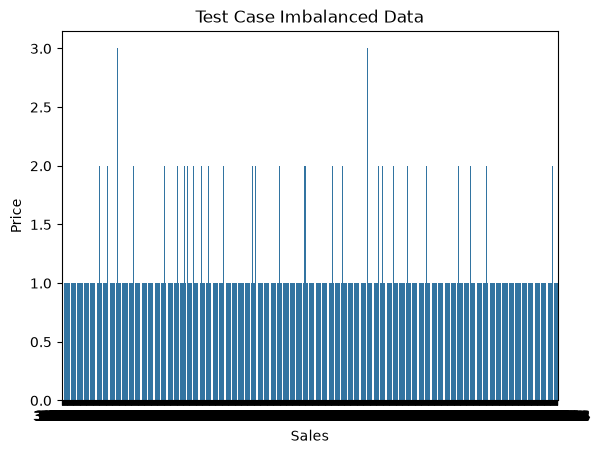

In [152]:

sns.countplot(x=y_test)

plt.title("Test Case Imbalanced Data")
plt.xlabel("Sales")
plt.ylabel("Price")
plt.show()

In [153]:
scaler = StandardScaler()
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [154]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(str(x_train_scaled))
print(str(x_test_scaled))

[[-0.73136461  0.72997769 -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 [-0.73136461 -1.29891286  1.57891233 ...  0.72358512 -0.35340753
  -0.35103988]
 [-0.73136461 -0.10544783 -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 ...
 [ 1.36730707  1.3267102   0.22328656 ... -1.38200742  2.8295945
  -0.35103988]
 [ 1.36730707  0.72997769 -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 [ 1.36730707  1.0880172   1.57891233 ...  0.72358512 -0.35340753
  -0.35103988]]
[[ 1.36730707  0.72997769 -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 [-0.73136461  0.72997769 -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 [-0.73136461  1.0880172  -1.13233922 ...  0.72358512 -0.35340753
  -0.35103988]
 ...
 [ 1.36730707  0.13324517  0.22328656 ...  0.72358512 -0.35340753
  -0.35103988]
 [-0.73136461  0.13324517  0.22328656 ...  0.72358512 -0.35340753
  -0.35103988]
 [ 1.36730707  0.13324517  0.22328656 ...  0.72358512 -0.35340753
  -0.35103988]]


## MACHINE LEARNING MODEL

## Linear Regression

In [155]:
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [156]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 1.3 ,-0.07,-0.62,..., 1.2 , 0.55,-0.35]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['Item Fat Content','Outlet Establishment Year','Outlet Size',..., 'Outlet Type_Supermarket Type1','Outlet Type_Supermarket Type2', 'Outlet Type_Supermarket Type3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,275.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(26)


In [157]:
y_pred = lr.predict(x_test)
y_pred

array([128.58184664, 140.40110838, 145.19025694, ..., 139.9842457 ,
       146.58676967, 126.61395439], shape=(1705,))

In [158]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [159]:
print("Linear Regression Results")
print("-" * 30)
print("R² Score :", r2)
print("MAE       :", mae)
print("MSE       :", mse)
print("RMSE      :", rmse)

Linear Regression Results
------------------------------
R² Score : 0.013872793866903321
MAE       : 52.372711954843794
MSE       : 3906.449428497726
RMSE      : 62.501595407619206


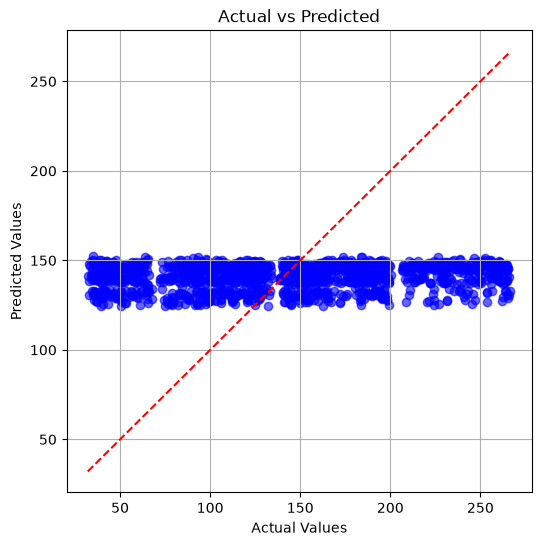

In [160]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

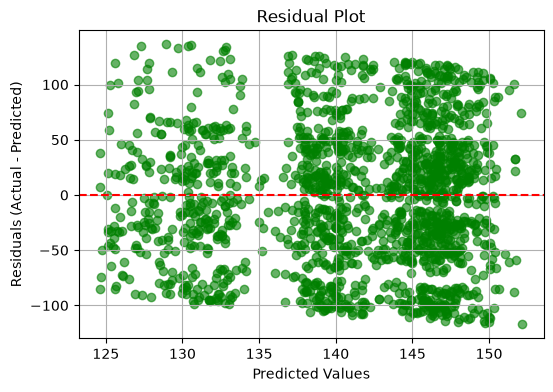

In [161]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

## Decision Tree Regression

In [162]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth = 3
)
dt_model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [163]:
dt_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [164]:
y_pred_dt = dt_model.predict(x_test)
y_pred_dt

array([151.44159516, 143.87795301, 143.87795301, ..., 143.87795301,
       143.87795301, 124.09064334], shape=(1705,))

In [165]:
r2 = r2_score(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)

In [166]:
print("Decision Tree Regression Results")
print("-" * 30)
print("R² Score :", r2)
print("MAE       :", mae)
print("MSE       :", mse)
print("RMSE      :", rmse)

Decision Tree Regression Results
------------------------------
R² Score : 0.01466400283734981
MAE       : 52.27318274531935
MSE       : 3903.3151291789363
RMSE      : 62.47651662167903


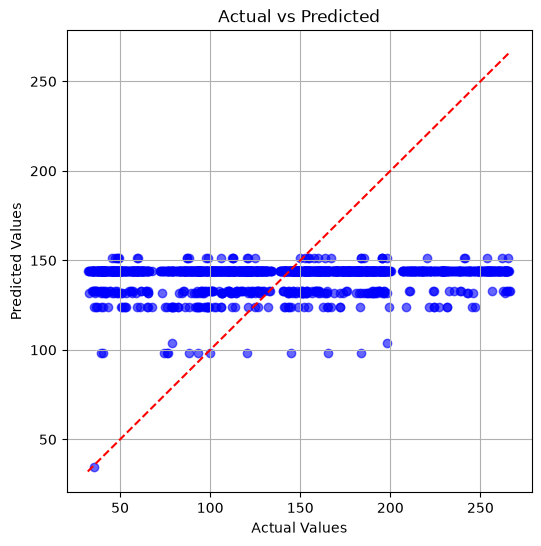

In [167]:
## Actual vs Predicted Plot for Decision Tree Regression
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

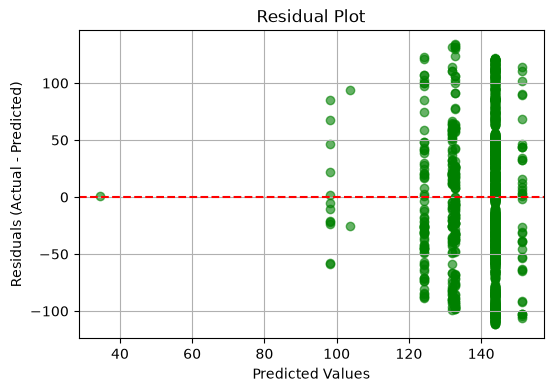

In [168]:
## Residual Plot for Decision Tree Regression
residuals = y_test - y_pred_dt

plt.figure(figsize=(6,4))
plt.scatter(y_pred_dt, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

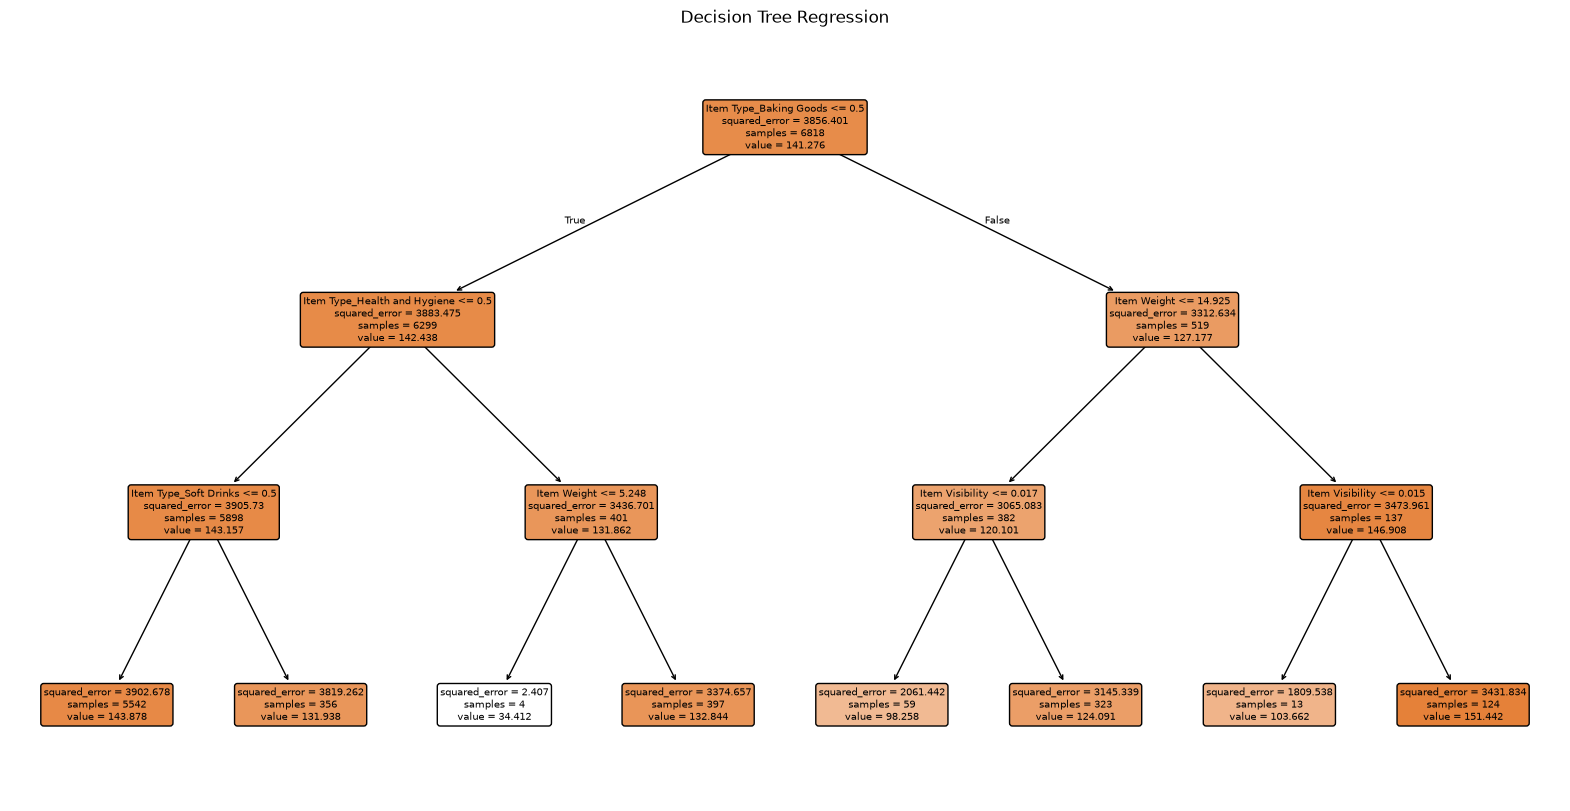

In [169]:
## Decision Tree Structure
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    filled=True,
    rounded=True,
    feature_names=x.columns
)

plt.title("Decision Tree Regression")
plt.show()

## Random Forest Regression  

In [170]:
rf_model = RandomForestRegressor(
    random_state=42,
    max_depth=3
)
rf_model

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [171]:
rf_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [172]:
y_pred_rf = rf_model.predict(x_test)
y_pred_rf

array([141.10618411, 140.51088894, 144.99887972, ..., 141.41432916,
       141.26882611, 124.16201508], shape=(1705,))

## Evaluation Metrics

In [173]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

In [174]:
print("Random Forest Regression Results")
print("-" * 30)
print("R² Score :", r2_rf)
print("MAE       :", mae_rf)
print("MSE       :", mse_rf)
print("RMSE      :", rmse_rf)

Random Forest Regression Results
------------------------------
R² Score : 0.022238196674077337
MAE       : 52.13752507551891
MSE       : 3873.3106784338443
RMSE      : 62.23592755341439


## Model Visualization

Actual vs Predicted Plot for Random Forest Regression Model

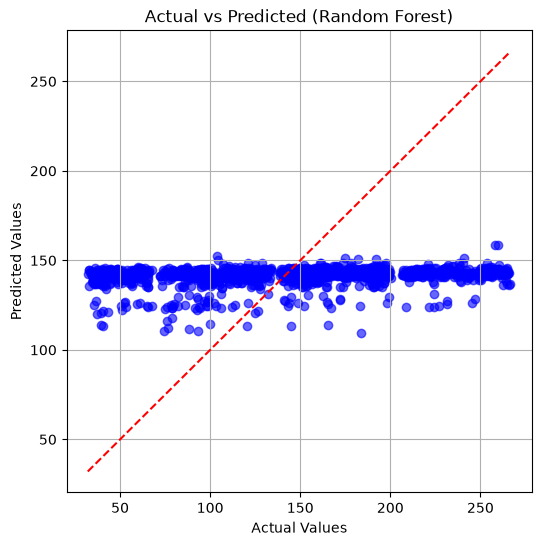

In [175]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red', linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()

Residual Plot for Random Forest Regression Model

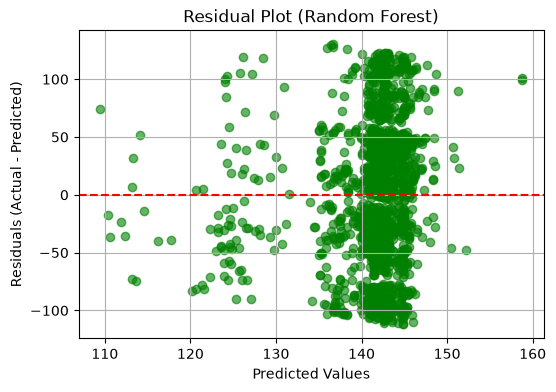

In [176]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Random Forest)")
plt.grid(True)
plt.show()

Random Forest Regression Structure

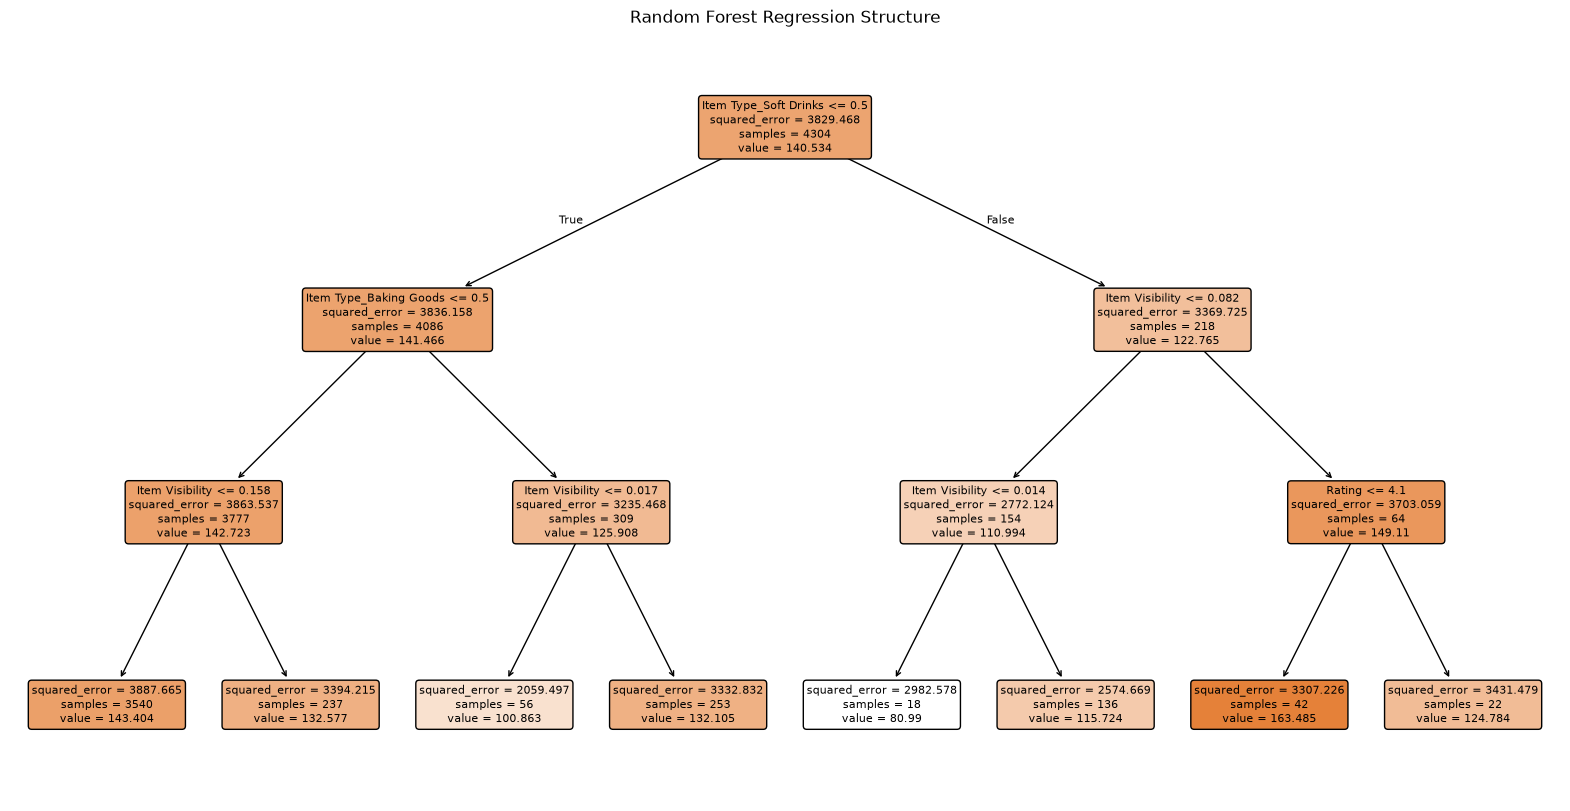

In [177]:
plt.figure(figsize=(20, 10))

plot_tree(
    rf_model.estimators_[0],
    filled=True,
    rounded=True,
    feature_names=x_train.columns,
)
plt.title("Random Forest Regression Structure")
plt.show()